# Radial Basis Function

Propriedades da RBF:
1. Vetor de entrdaa n-dimensional
2. Neurônios RBF -> Cada neurônio na camada oculta representa um vetor protótipo do conjunto de treinamento. A rede calcula a distância euclidiana entre o vetor de entrada e o centro de cada neurônio
3. Função de Ativação: A distância euclidiana é transformada usando uma função de base radial (tipicamente uma função gaussiana) para calcular o valor de ativação do neurônio. Esse valor diminui exponencialmente à medida que a distância aumenta.
4. Nós de Saída: Cada nó de saída calcula uma pontuação com base na soma ponderada dos valores de ativação de **todos** os neurônios RBF. Para a classificação, a categoria com a maior pontuação é escolhida

Principais características dos RBFs
* Funções de Base Radial : São funções de valor real que dependem exclusivamente da distância a partir de um ponto central. A função gaussiana é o tipo mais comumente usado.
* Dimensionalidade : As dimensões da rede correspondem ao número de variáveis ​​preditoras.
* Centro e Raio : Cada neurônio RBF possui um centro e um raio (dispersão). O raio afeta a abrangência da influência de cada neurônio no espaço de entrada.

material do [GeekForGeeks](https://www.geeksforgeeks.org/deep-learning/what-are-radial-basis-function-neural-networks/)

In [168]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons
import sklearn.metrics as sm

In [169]:
#Dados de entrada
X, y = make_moons(n_samples=300, noise=0.1)

#como o y original é do tipo {0, 1}, é necessário ajustar para -1, 1
y =  2*y -1

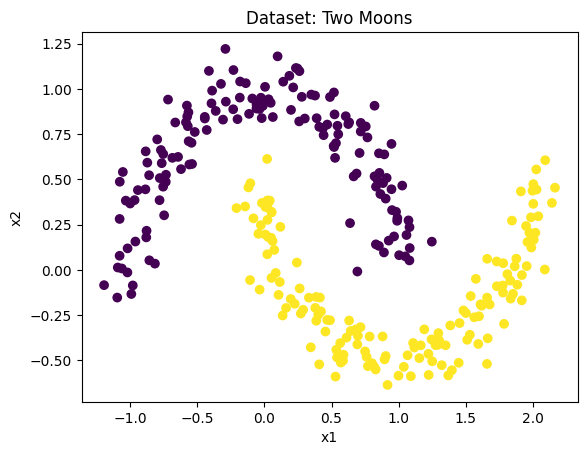

In [170]:
# plot
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Dataset: Two Moons")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [171]:
''' Função RBF
Aplicando a transformação não linear para o espaço de caracteristicas da RBF
usando uma função de base radial Gaussiana
x → entrada
c → centro (do K-means, por exemplo)
s → sigma (largura da gaussiana)
'''
def rbf(x, cent, sig):
    return np.exp(-np.linalg.norm(x - cent) ** 2 / (2 * sig **2))

In [172]:
def matrix_R(Vetor_entrada, centros, sigma):
    R = np.zeros((Vetor_entrada.shape[0], len(centros)))

    for i in range(Vetor_entrada.shape[0]):
        for j in range(len(centros)):
            R[i,j] =  rbf(Vetor_entrada[i], centros[j], sigma)
        
    return R
        

In [173]:
def rbf_network(X, centros, sigma, W):
    R = matrix_R(X, centros, sigma)
    return np.dot(R, W)

### Treinamento

Aplicando o Kmeans pra encontrar as centroides

In [174]:
kmeans = KMeans(n_clusters=10).fit(X)
centros = kmeans.cluster_centers_

Calculando os paramteros da funcao radial

In [175]:
distancia_max = np.max( cdist(centros, centros, 'euclidean'))
sigma = distancia_max / np.sqrt(2 * len(centros))

In [176]:
#Matrix R
R =  matrix_R(X, centros, sigma)
#vetor de pesos
W = np.dot(np.linalg.pinv(R), y)

Terceira Etapa: Treinamento dos pesos de saida





In [177]:
y_pred =  rbf_network(X, centros, sigma, W)

#Passando do continuo pro discreto [-1,1]
y_pred_class = np.sign(y_pred)

print(y_pred[:10])
print(y_pred_class[:10])

[-1.07944979 -0.74385166  0.87382002  0.42481382  1.09496365 -0.25598864
  1.06873645 -0.62334732  0.98361689  0.88315247]
[-1. -1.  1.  1.  1. -1.  1. -1.  1.  1.]


In [178]:
#Calculando a acuracia e erro medio quadratico do modelo
mse = sm.mean_squared_error(y, y_pred)
acc = np.mean(y_pred_class == y)
print("MSE: ", mse)
print("Acuracia: ", acc)

MSE:  0.06351423370899922
Acuracia:  0.9966666666666667


In [179]:
#novos exemplos
# novo ponto
x_novo = np.array([[0.2, 0.8]])

y_novo = rbf_network(x_novo, centros, sigma, W)
y_novo_class = np.sign(y_novo)

print("Predição:", y_novo_class)

Predição: [-1.]


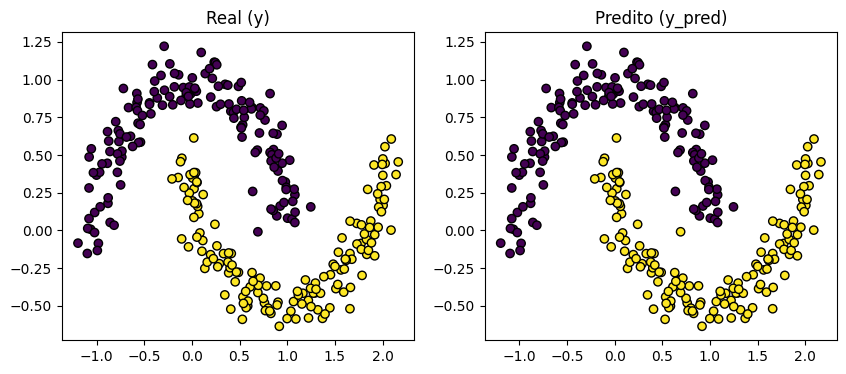

In [180]:

plt.figure(figsize=(10,4))

# valores reais
plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
plt.title("Real (y)")

# valores preditos
plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], c=y_pred_class, edgecolors='k')
plt.title("Predito (y_pred)")
plt.show()

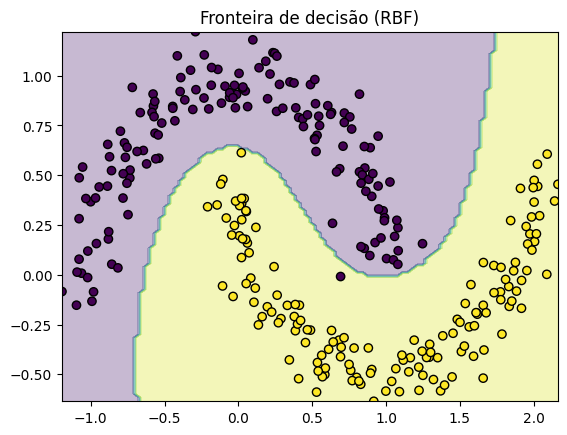

In [181]:
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 100),
    np.linspace(X[:,1].min(), X[:,1].max(), 100)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = rbf_network(grid, centros, sigma, W)
Z = np.sign(Z)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
plt.title("Fronteira de decisão (RBF)")
plt.show()

### Comparativo apara diferentes valores de K

In [182]:
#Unificando os procediemntos numa unica chamada
def train_rbf(X, y, K):
    # K-means
    kmeans = KMeans(n_clusters=K, random_state=42).fit(X)
    centros = kmeans.cluster_centers_

    # sigma
    dist_max = np.max(cdist(centros, centros))
    sigma = dist_max / np.sqrt(2 * K)

    # matriz R
    R = matrix_R(X, centros, sigma)

    # pesos
    W = np.dot(np.linalg.pinv(R), y)

    return centros, sigma, W

def predict_rbf(X, centros, sigma, W):
    R = matrix_R(X, centros, sigma)
    y_pred = np.dot(R, W)
    return np.sign(y_pred), y_pred

In [183]:
Ks = [1, 5, 10, 15, 50]

resultados = []

for K in Ks:
    centros, sigma, W = train_rbf(X, y, K)
    
    y_pred_class, y_pred = predict_rbf(X, centros, sigma, W)
    
    mse = sm.mean_squared_error(y, y_pred)
    acc = sm.accuracy_score(y, y_pred_class)
    
    resultados.append((K, mse, acc))

# =========================
# 4. Mostrar resultados
# =========================
print("K | MSE | Acurácia")
for r in resultados:
    print(f"{r[0]} | {r[1]:.4f} | {r[2]:.4f}")

/tmp/ipykernel_36232/2886222911.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  return np.exp(-np.linalg.norm(x - cent) ** 2 / (2 * sig **2))


K | MSE | Acurácia
1 | 1.0000 | 0.0000
5 | 0.2606 | 0.9200
10 | 0.0455 | 0.9967
15 | 0.0282 | 0.9967
50 | 0.0062 | 1.0000


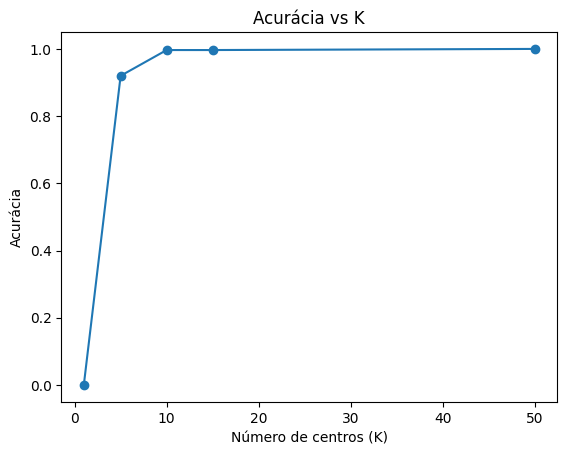

In [184]:

Ks_vals = [r[0] for r in resultados]
mse_vals = [r[1] for r in resultados]
acc_vals = [r[2] for r in resultados]

plt.figure()

plt.plot(Ks_vals, acc_vals, marker='o')
plt.title("Acurácia vs K")
plt.xlabel("Número de centros (K)")
plt.ylabel("Acurácia")

plt.show()